In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from IPython.core.pylabtools import figsize

sys.path.append('..//')
from utils_mitgcm import open_mitgcm_ds_from_config
from utils_energy_analysis import *

In [2]:
lake = 'zug'
model = f'{lake}_2025'
mitgcm_config, ds = open_mitgcm_ds_from_config('..//config.json', model)

In [3]:
folder_path = os.path.dirname(mitgcm_config['datapath'])
output_folder = os.path.join(folder_path, "chaos_analysis")
os.makedirs(output_folder, exist_ok=True)

In [4]:
grid_resolution = 100
ds['YC'] = np.arange(1, len(ds['YC']) + 1) * grid_resolution - grid_resolution / 2
ds['XC'] = np.arange(1, len(ds['XC']) + 1) * grid_resolution - grid_resolution / 2
ds['YG'] = np.arange(0, len(ds['YG'])) * grid_resolution
ds['XG'] = np.arange(0, len(ds['XG'])) * grid_resolution

In [5]:
mask = ds['THETA'].isel(time=0).values > 0

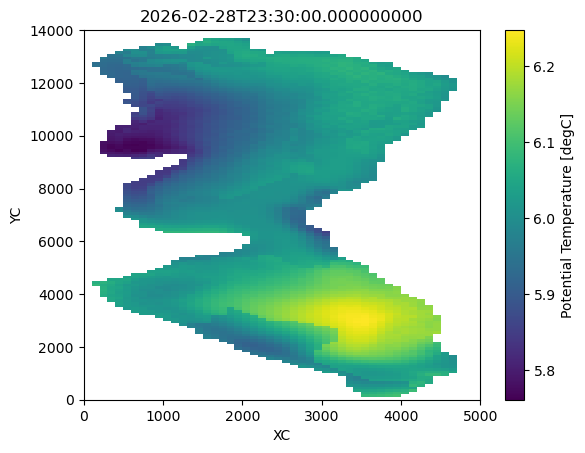

In [6]:
%matplotlib inline
t=-1
plt.close('all')
#plt.figure(figsize=(15,7))
ds_sel = ds['THETA'].isel(Z=0, time=t)
ds_sel.where(ds_sel != 0, np.nan).plot()
plt.title(ds_sel.time.values)
#plt.savefig(r"/home/leroquan@eawag.wroot.emp-eaw.ch/work_space/dummy_extended/figures/transect_location.png")
plt.show()

In [ ]:
tt=50
z_lim=16
list_idx_chaos = []
for tt in range(len(ds['time'])):
    idx_chaos=0
    for zz in range(z_lim):
        u_sign_change = np.sum(np.diff(np.sign(ds['UVEL'].isel(time=tt, Z=zz).values)) != 0)
        v_sign_change = np.sum(np.diff(np.sign(ds['VVEL'].isel(time=tt, Z=zz).values)) != 0)
        idx_chaos += (u_sign_change + v_sign_change) / np.sum(mask[:z_lim])
    list_idx_chaos.append(idx_chaos)

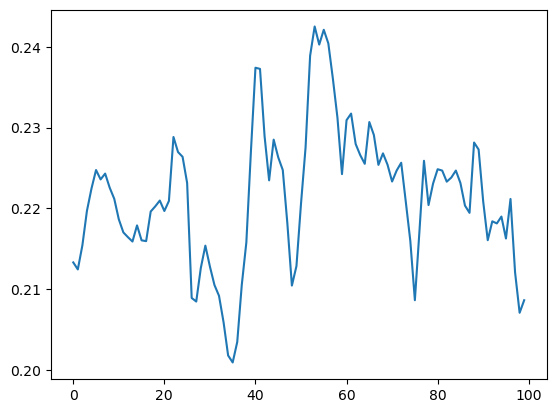

In [ ]:
plt.plot(list_idx_chaos)